# Índice de Contenidos del Proyecto

## 1. Configuración del Entorno y Preprocesamiento de Datos
* ### 1.1. Gestión de Datos y Auditoría
* ### 1.2. Pipeline de Transformación y Vectorización

## 2. Extracción de Características Clásicas (HOG, LBP, HSV) y Modelos Tradicionales
* ### 2.1. Descriptores de Visión
* ### 2.2. Benchmark Tradicional

## 3. Modelado Avanzado Mediante Redes Neuronales Artificiales (ANN)
* ### 3.1. Entorno y Preparación
* ### 3.2. Arquitecturas y Ablación

## 4. Aprendizaje No Supervisado: Reducción Dimensional y Análisis de Clustering
* ### 4.1. Reducción y Diagnóstico Geométrico
* ### 4.2. Optimización y Benchmark de Clustering

# 1. Configuración del Entorno y Preprocesamiento de Datos
## 1.1. Importación de Librerías y Módulos del Sistema

In [1]:
!pip install --extra-index-url=https://pypi.nvidia.com cudf-cu12 cuml-cu12

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [2]:
!pip install datasets Pillow opencv-python-headless torch torchvision -q

In [3]:
!pip install datasets pandas numpy matplotlib seaborn plotly wordcloud -q imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.2 MB/s eta 0:00:00


In [2]:
import io
import gc
import os
import time
import warnings
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from joblib import Parallel, delayed

import numpy as np
import pandas as pd

import cudf
import cuml

import cv2
import imagehash
from PIL import Image
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2hsv

import torch
import tensorflow as tf
from torchvision import transforms
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout, Input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from datasets import load_dataset, load_from_disk
from google.colab import drive

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, silhouette_score, classification_report
)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Librerías optimizadas e importadas correctamente.')

✅ Librerías optimizadas e importadas correctamente.


## 1.2. Carga del Dataset Inicial

Se realiza la lectura del conjunto de datos crudo para inicializar el flujo de trabajo. Este dataframe servirá como base para los análisis dimensionales y la posterior extracción de características físicas de los archivos de imagen.

In [3]:
drive.mount('/content/drive')

dataset_limpio = load_from_disk("/content/drive/MyDrive/Proyecto IA1/Datasets")

COLS = ['file_name', 'rarespecies_id', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'sciName', 'common']
cols_existentes = [c for c in COLS if c in dataset_limpio.column_names]
df_limpio = dataset_limpio.to_pandas()[cols_existentes]

print(f"✅ `df_limpio` creado con {len(df_limpio):,} filas y {len(df_limpio.columns)} columnas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ `df_limpio` creado con 11,825 filas y 11 columnas.


## 1.3. Extracción Multihilo de Características Visuales
Analiza las imágenes en paralelo utilizando hilos (`ThreadPoolExecutor`) para agilizar el proceso sin saturar la memoria. Convierte cada imagen a escala de grises para extraer mediante OpenCV sus propiedades físicas fundamentales: la media para el brillo, la desviación estándar para el contraste y la varianza del Laplaciano para medir la nitidez (enfoque).

In [5]:
def evaluar_imagen(i, dataset):
    resultado = {'idx': i, 'ancho': None, 'alto': None, 'ratio': None, 'brillo': None, 'contraste': None, 'nitidez': None, 'modo': None, 'es_cuadrada': False}
    try:
        img_data = dataset.loc[i, 'file_name']
        if isinstance(img_data, dict) and 'bytes' in img_data: img = Image.open(io.BytesIO(img_data['bytes']))
        elif isinstance(img_data, Image.Image): img = img_data
        else: raise ValueError("Unsupported image data format")
        resultado['modo'] = img.mode; img = img.convert('RGB'); w, h = img.size
        resultado['ancho'], resultado['alto'], resultado['ratio'], resultado['es_cuadrada'] = w, h, round(w / h, 3), (0.95 <= w/h <= 1.05)
        arr = np.array(img); gris = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        resultado['brillo'], resultado['contraste'], resultado['nitidez'] = float(gris.mean()), float(gris.std()), float(cv2.Laplacian(gris, cv2.CV_64F).var())
        del arr, gris, img
    except Exception: pass
    return resultado

MAX_WORKERS = os.cpu_count(); BATCH = 128; indices = list(range(len(df_limpio))); resultados = [None] * len(indices)
print(f"Evaluando {len(df_limpio):,} imágenes con {MAX_WORKERS} workers..."); t0 = time.time()

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futuros = {executor.submit(evaluar_imagen, i, df_limpio): i for i in indices}
    for futuro in tqdm(as_completed(futuros), total=len(indices), desc="Evaluando"):
        i = futuros[futuro]
        try:
            resultados[i] = futuro.result()
        except Exception as e:
            print(f"Error en imagen {i}: {e}"); resultados[i] = {'idx': i}
        if sum(1 for r in resultados if r is not None) % (BATCH * 10) == 0: gc.collect()

df_eval = pd.DataFrame([r for r in resultados if r is not None]); print(f"✅ Completado en {time.time()-t0:.0f}s")
display(df_eval.head(3))

Evaluando 11,825 imágenes con 2 workers...


Evaluando: 100%|██████████| 11825/11825 [14:51<00:00, 13.27it/s]

✅ Completado en 891s


,idx,ancho,alto,ratio,brillo,contraste,nitidez,modo,es_cuadrada
0,0,400,400,1.000,101.645313,32.779471,3219.593444,RGB,True
1,1,1596,1066,1.497,168.982406,39.121761,115.771438,RGB,False
2,2,2480,1396,1.777,57.684533,66.928274,207.646137,RGB,False


## 1.4. Diagnóstico Estadístico de Calidad Visual
Genera un tablero de control gráfico con seis subplots (`2x3`) para auditar la calidad técnica de los datos. Muestra histogramas de brillo, contraste, nitidez y dimensiones de las imágenes para identificar anomalías visuales (muestras oscuras, borrosas o con tamaños incorrectos) y resume la cantidad total de problemas detectados.

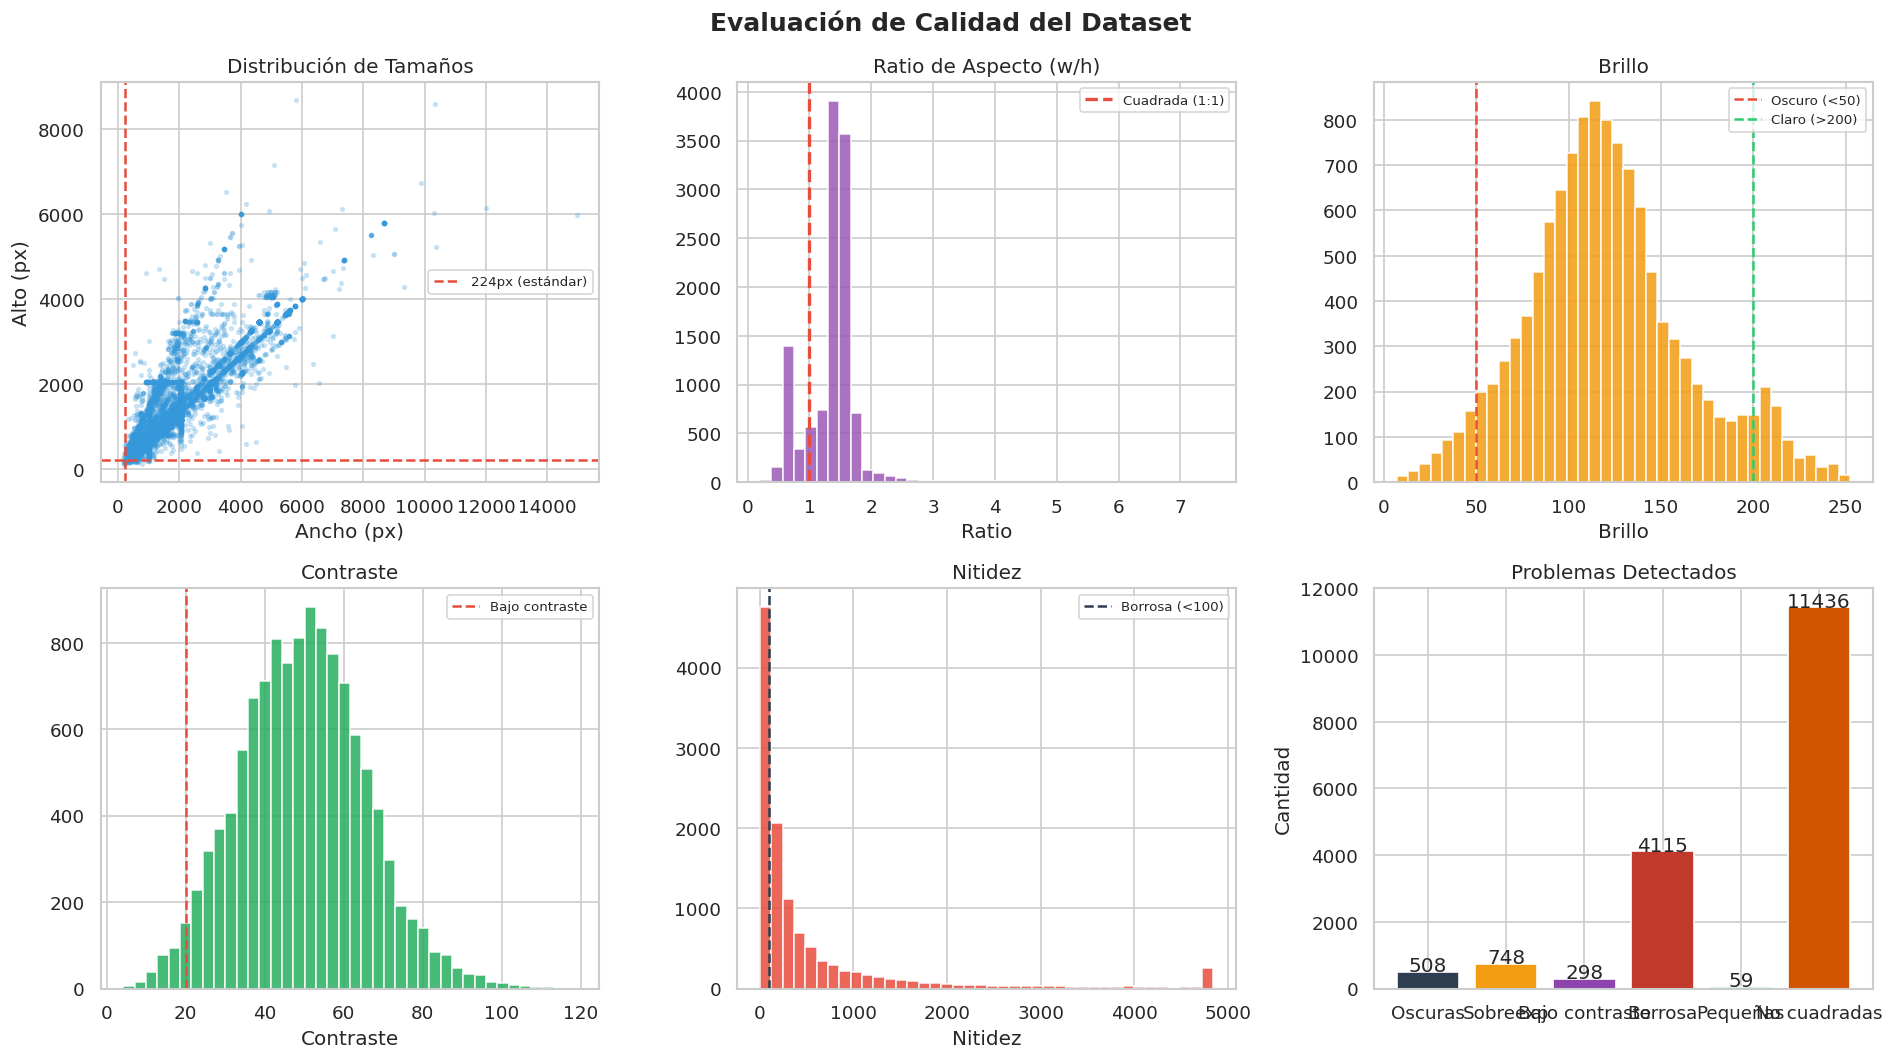

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Evaluación de Calidad del Dataset', fontsize=15, fontweight='bold')

axes[0,0].scatter(df_eval['ancho'], df_eval['alto'], alpha=0.2, s=5, color='#3498db')
axes[0,0].axvline(224, color='#e74c3c', linestyle='--', linewidth=1.5, label='224px (estándar)')
axes[0,0].axhline(224, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[0,0].set_title('Distribución de Tamaños')
axes[0,0].set_xlabel('Ancho (px)')
axes[0,0].set_ylabel('Alto (px)')
axes[0,0].legend(fontsize=8)

axes[0,1].hist(df_eval['ratio'], bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0,1].axvline(1.0, color='#e74c3c', linestyle='--', linewidth=2, label='Cuadrada (1:1)')
axes[0,1].set_title('Ratio de Aspecto (w/h)')
axes[0,1].set_xlabel('Ratio')
axes[0,1].legend(fontsize=8)

axes[0,2].hist(df_eval['brillo'], bins=40, color='#f39c12', edgecolor='white', alpha=0.85)
axes[0,2].axvline(50, color='#e74c3c', linestyle='--', linewidth=1.5, label='Oscuro (<50)')
axes[0,2].axvline(200, color='#2ecc71', linestyle='--', linewidth=1.5, label='Claro (>200)')
axes[0,2].set_title('Brillo')
axes[0,2].set_xlabel('Brillo')
axes[0,2].legend(fontsize=8)

axes[1,0].hist(df_eval['contraste'], bins=40, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1,0].axvline(20, color='#e74c3c', linestyle='--', linewidth=1.5, label='Bajo contraste')
axes[1,0].set_title('Contraste')
axes[1,0].set_xlabel('Contraste')
axes[1,0].legend(fontsize=8)

nitidez_clip = df_eval['nitidez'].clip(upper=df_eval['nitidez'].quantile(0.98))
axes[1,1].hist(nitidez_clip, bins=40, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1,1].axvline(100, color='#2c3e50', linestyle='--', linewidth=1.5, label='Borrosa (<100)')
axes[1,1].set_title('Nitidez')
axes[1,1].set_xlabel('Nitidez')
axes[1,1].legend(fontsize=8)

n_oscuras = (df_eval['brillo'] < 50).sum()
n_sobreexp = (df_eval['brillo'] > 200).sum()
n_bajo_cont = (df_eval['contraste'] < 20).sum()
n_borrosas = (df_eval['nitidez'] < 100).sum()
n_pequenas = ((df_eval['ancho'] < 224) | (df_eval['alto'] < 224)).sum()
n_no_cuad = (~df_eval['es_cuadrada']).sum()

cats = ['Oscuras', 'Sobreexp', 'Bajo contraste', 'Borrosa', 'Pequeñas', 'No cuadradas']
vals = [n_oscuras, n_sobreexp, n_bajo_cont, n_borrosas, n_pequenas, n_no_cuad]

bars = axes[1,2].bar(cats, vals, color=['#2c3e50','#f39c12','#8e44ad','#c0392b','#16a085','#d35400'])
axes[1,2].set_title('Problemas Detectados')
axes[1,2].set_ylabel('Cantidad')

for bar, val in zip(bars, vals):
    axes[1,2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val}',
        ha='center'
    )

plt.tight_layout()
plt.savefig('evaluacion_calidad.png', dpi=120, bbox_inches='tight')
plt.show()

## 1.5. Función del Semáforo de Aptitud
Implementa un sistema de auditoría por umbrales estadísticos que calcula el porcentaje de éxito global de cada métrica física. Clasifica el estado general de las imágenes usando indicadores intuitivos (🟢 óptimo si supera el 90%, 🟡 aceptable desde el 70%, o 🔴 crítico), imprimiendo en consola una alerta explícita sobre la viabilidad de entrenar los modelos.

In [6]:
def semaforo_calidad(df):
    n = len(df); print("\n" + "="*55); print("   SEMÁFORO DE APTITUD PARA MODELO"); print("="*55)
    checks = {
        "Imágenes >= 224px": ((df['ancho'] >= 224) & (df['alto'] >= 224)).mean(),
        "Brillo adecuado (50-200)": ((df['brillo'] >= 50) & (df['brillo'] <= 200)).mean(),
        "Contraste suficiente": (df['contraste'] >= 20).mean(),
        "Nitidez suficiente": (df['nitidez'] >= 100).mean(),
        "Ratio de aspecto ok": df['es_cuadrada'].mean(),
    }
    todo_ok = True
    for nombre, pct in checks.items():
        if pct >= 0.90: icono, estado = "🟢", "ÓPTIMO"
        elif pct >= 0.70: icono, estado, todo_ok = "🟡", "ACEPTABLE", False
        else: icono, estado, todo_ok = "🔴", "REQUIERE ATENCIÓN", False
        print(f"  {icono} {nombre:<28} {pct*100:5.1f}%  {estado}")
    print("="*55); print("  ✅ Dataset listo para entrenar" if todo_ok else "  ⚠️  Aplica el preprocesamiento sugerido abajo"); print("="*55)
    return checks

checks = semaforo_calidad(df_eval)


   SEMÁFORO DE APTITUD PARA MODELO
  🟢 Imágenes >= 224px             99.5%  ÓPTIMO
  🟡 Brillo adecuado (50-200)      89.4%  ACEPTABLE
  🟢 Contraste suficiente          97.5%  ÓPTIMO
  🔴 Nitidez suficiente            65.2%  REQUIERE ATENCIÓN
  🔴 Ratio de aspecto ok            3.3%  REQUIERE ATENCIÓN
  ⚠️  Aplica el preprocesamiento sugerido abajo


## 1.6. Pipeline Adaptativo de Transformación de Imágenes
Diseña un flujo automatizado de preprocesamiento y aumentación de datos utilizando `torchvision.transforms`. Si el diagnóstico del semáforo muestra que más del 5% de las muestras tienen defectos de enfoque o iluminación, el pipeline añade dinámicamente pasos de corrección estocástica (`RandomAdjustSharpness` y `ColorJitter`) para estabilizar el dataset de forma automática.

In [7]:
def generar_transforms(df_eval):
    ancho_medio, alto_medio, brillo_medio = int(df_eval['ancho'].median()), int(df_eval['alto'].median()), df_eval['brillo'].mean()
    hay_borrosas = (df_eval['nitidez'] < 100).mean() > 0.05
    hay_oscuras = (df_eval['brillo'] < 50).mean() > 0.05
    hay_bajo_contraste = (df_eval['contraste'] < 20).mean() > 0.05
    print("Pipeline de transforms generado:\n")
    pytorch_pasos_train, pytorch_pasos_val = [], []

    print("PyTorch: Resize(256) + CenterCrop(224)")
    pytorch_pasos_train.extend([transforms.Resize(256), transforms.CenterCrop(224)])
    pytorch_pasos_val.extend([transforms.Resize(256), transforms.CenterCrop(224)])
    print("PyTorch: RandomHorizontalFlip"); pytorch_pasos_train.append(transforms.RandomHorizontalFlip())
    print("PyTorch: RandomRotation(15)"); pytorch_pasos_train.append(transforms.RandomRotation(15))

    if hay_borrosas: print("PyTorch: RandomAdjustSharpness"); pytorch_pasos_train.append(transforms.RandomAdjustSharpness(2.0, p=0.3))
    if hay_oscuras or hay_bajo_contraste: print("PyTorch: ColorJitter"); pytorch_pasos_train.append(transforms.ColorJitter(brightness=0.3, contrast=0.3))

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    pytorch_pasos_train.extend([transforms.ToTensor(), normalize]); pytorch_pasos_val.extend([transforms.ToTensor(), normalize])
    pytorch_train_transforms, pytorch_val_transforms = transforms.Compose(pytorch_pasos_train), transforms.Compose(pytorch_pasos_val)

    numpy_pasos_train, numpy_pasos_val = [], []
    print("\nNumPy: Resize((64, 64))")
    numpy_pasos_train.append(transforms.Resize((64, 64))); numpy_pasos_val.append(transforms.Resize((64, 64)))
    print("NumPy: RandomHorizontalFlip"); numpy_pasos_train.append(transforms.RandomHorizontalFlip())
    print("NumPy: RandomRotation(15)"); numpy_pasos_train.append(transforms.RandomRotation(15))

    if hay_borrosas: print("NumPy: RandomAdjustSharpness"); numpy_pasos_train.append(transforms.RandomAdjustSharpness(2.0, p=0.3))
    if hay_oscuras or hay_bajo_contraste: print("NumPy: ColorJitter"); numpy_pasos_train.append(transforms.ColorJitter(brightness=0.3, contrast=0.3))
    numpy_train_transforms, numpy_val_transforms = transforms.Compose(numpy_pasos_train), transforms.Compose(numpy_pasos_val)

    return pytorch_train_transforms, pytorch_val_transforms, numpy_train_transforms, numpy_val_transforms

py_train_t, py_val_t, np_train_t, np_val_t = generar_transforms(df_eval)

Pipeline de transforms generado:

PyTorch: Resize(256) + CenterCrop(224)
PyTorch: RandomHorizontalFlip
PyTorch: RandomRotation(15)
PyTorch: RandomAdjustSharpness

NumPy: Resize((64, 64))
NumPy: RandomHorizontalFlip
NumPy: RandomRotation(15)
NumPy: RandomAdjustSharpness


## 1.7. Procesamiento Paralelo y Vectorización en NumPy
Define un motor concurrente multihilo protegido con exclusión mutua (`threading.Lock`) para manejar errores de archivos dañados de manera segura. Aplica las transformaciones dinámicas anteriores sobre cada muestra, estandariza las imágenes a un tamaño compacto de $64 \times 64$ en formato RGB y las aplana en vectores estructurados unidimensionales compatibles con clasificadores clásicos.

In [8]:
error_lock = threading.Lock(); errores_cont = [0]

def procesar_imagen_cpu(args):
    idx, row, label_map, transform = args
    try:
        img_data = row['file_name']
        if isinstance(img_data, dict) and 'bytes' in img_data: img = Image.open(io.BytesIO(img_data['bytes']))
        elif isinstance(img_data, Image.Image): img = img_data
        else: raise ValueError("Formato no soportado")
        if transform: img = transform(img)
        if img.mode != 'RGB': img = img.convert('RGB')
        if img.size != (64, 64): img = img.resize((64, 64))
        arr = np.array(img)
        if arr.shape != (64, 64, 3): raise ValueError(f"Shape inesperado: {arr.shape}")
        return (idx, arr.flatten().astype(np.float32), label_map[row['class']])
    except Exception:
        with error_lock: errores_cont[0] += 1
        return None

def dataset_to_numpy_parallel_cpu(df, transform=None, max_workers=None):
    especies = list(df['class'].unique()); label_map = {esp: i for i, esp in enumerate(especies)}
    print(f"🔍 Clases: {len(label_map)} | Workers: {max_workers or os.cpu_count()}"); args_list = [(idx, row, label_map, transform) for idx, row in df.iterrows()]
    resultados_dict = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futuros = {executor.submit(procesar_imagen_cpu, args): args[0] for args in args_list}
        for futuro in tqdm(as_completed(futuros), total=len(args_list), desc="CPU Procesando"):
            resultado = futuro.result()
            if resultado is not None: idx, arr, label = resultado; resultados_dict[idx] = (arr, label)
    X, y = [], []
    for idx, _ in df.iterrows():
        if idx in resultados_dict: arr, label = resultados_dict[idx]; X.append(arr); y.append(label)
    print(f"⚠️ Imágenes descartadas: {errores_cont[0]}")
    return np.array(X, dtype=np.float32), np.array(y), label_map

## 1.8. Ejecución de la Conversión Concurrente
Ejecuta la llamada formal del pipeline multihilo sobre el dataset limpio para materializar los arreglos definitivos: la matriz de variables predictoras continuas ($X$), el vector correlativo de etiquetas ($y$) y el mapeo de categorías numéricas correspondientes.

In [9]:
X, y, label_map = dataset_to_numpy_parallel_cpu(
    df_limpio,
    transform   = np_val_t,
    max_workers = os.cpu_count()
)

🔍 Clases: 15 | Workers: 2


CPU Procesando: 100%|██████████| 11825/11825 [06:14<00:00, 31.54it/s]


⚠️ Imágenes descartadas: 0


## 1.9. Partición Estrecha del Dataset y Escalado de Características
Divide las matrices de datos en conjuntos de entrenamiento (80%) y prueba (20%) utilizando una estrategia estratificada (`stratify=y`) para mantener la proporción original de clases. Posteriormente, aplica un escalado estándar (`StandardScaler`) que normaliza las características con media cero y varianza unitaria, calculando los parámetros únicamente sobre el conjunto de entrenamiento para evitar el sesgo por fuga de información (*data leakage*).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (9460, 12288)
Test: (2365, 12288)


# 2. Extracción de Características Clásicas (HOG, LBP, HSV) y Modelos Tradicionales


## 2.1. Definición del Pipeline Computacional de Descriptores Visuales
Define las funciones matemáticas para extraer descriptores específicos de visión por computadora a partir de las matrices de píxeles: el histograma de gradientes orientados (`HOG`) para capturar contornos y bordes, los patrones binarios locales (`LBP`) para caracterizar texturas espaciales, y un histograma global concatenado en el espacio de color `HSV` para modelar la distribución cromática. Finalmente, paraleliza la ejecución sobre todo el conjunto de datos mediante un backend optimizado para consolidar una nueva matriz de características de alta fidelidad.

In [ ]:
def extraer_hog(img_arr: np.ndarray) -> np.ndarray:
    gris = 0.299 * img_arr[:, :, 0] + 0.587 * img_arr[:, :, 1] + 0.114 * img_arr[:, :, 2]
    feat = hog(
        gris, orientations=9, pixels_per_cell=(8, 8),
        cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True
    )
    return feat

def extraer_lbp(img_arr: np.ndarray, P: int = 24, R: float = 3.0) -> np.ndarray:
    gris = 0.299 * img_arr[:, :, 0] + 0.587 * img_arr[:, :, 1] + 0.114 * img_arr[:, :, 2]
    lbp_map = local_binary_pattern(gris, P=P, R=R, method='uniform')
    n_bins = P + 2
    hist, _ = np.histogram(lbp_map.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

def extraer_color_hsv(img_arr: np.ndarray, bins_por_canal: int = 32) -> np.ndarray:
    if img_arr.max() > 1.0:
        img_arr = img_arr / 255.0
    hsv = rgb2hsv(img_arr.astype(np.float32))
    rangos = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
    canales = []
    for c in range(3):
        hist, _ = np.histogram(hsv[:, :, c].ravel(), bins=bins_por_canal, range=rangos[c], density=True)
        canales.append(hist)
    return np.concatenate(canales)

def extraer_features_clasicas(img_arr: np.ndarray) -> np.ndarray:
    hog_feat   = extraer_hog(img_arr)
    lbp_feat   = extraer_lbp(img_arr)
    color_feat = extraer_color_hsv(img_arr)
    return np.concatenate([hog_feat, lbp_feat, color_feat])

def procesar_fila(x_row: np.ndarray, y_label):
    try:
        arr = x_row.reshape(64, 64, 3)
        feat = extraer_features_clasicas(arr)
        return feat, y_label
    except Exception:
        return None, None

def extract_from_XY(X, Y, n_jobs=-1):
    X_arr = np.asarray(X, dtype=np.float32)
    Y_arr = np.asarray(Y)
    print(f" Extrayendo descriptores de {X_arr.shape[0]} imágenes en paralelo...")

    resultados = Parallel(n_jobs=n_jobs, backend='loky', verbose=3)(
        delayed(procesar_fila)(x_row, y_label) for x_row, y_label in zip(X_arr, Y_arr)
    )
    validos = [(f, l) for f, l in resultados if f is not None]
    X_features = np.array([f for f, _ in validos], dtype=np.float32)
    Y_features = np.array([l for _, l in validos])
    print(f" Extracción completada. Nuevo shape de X: {X_features.shape}")
    return X_features, Y_features


## 2.2. Diseño de la Infraestructura Adaptativa y Benchmark de Clasificadores Tradicionales
Configura un entorno híbrido de ejecución que detecta de forma automática la disponibilidad de aceleración por hardware mediante las librerías RAPIDS `cuML` y `cuDF`. La rutina prepara una subpartición de datos y ejecuta un Análisis de Componentes Principales (`PCA`) adaptativo para reducir las dimensiones de los descriptores clásicos, preservando el 95% de la varianza estadística del espacio original. Finalmente, inicializa un pipeline comparativo para instanciar algoritmos tradicionales (Árboles de Decisión, Naive Bayes, Bosques Aleatorios y Máquinas de Soporte Vectorial) adaptando el motor de cálculo según la infraestructura del sistema.

In [ ]:
try:
    _ = cuml.PCA(n_components=1)
    USE_GPU = True
    print(" RAPIDS cuML and cuDF found and GPU available. Using GPU acceleration.")
except Exception as e:
    USE_GPU = False
    print(f" RAPIDS cuML or cuDF not found or GPU not available: {e}. Using CPU (scikit-learn).")

def ejecutar_benchmark_modelos(X_nuevas, Y_nuevas):
    le = LabelEncoder()
    Y_codificadas = le.fit_transform(Y_nuevas)

    X_train, X_test, y_train, y_test = train_test_split(
        X_nuevas, Y_codificadas, test_size=0.2, random_state=42, stratify=Y_codificadas
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    temp_pca = PCA(n_components=0.95, random_state=42)
    temp_pca.fit(X_train_scaled)
    n_components_pca = temp_pca.n_components_

    print(f"\n PCA will reduce to {n_components_pca} dimensions for 95% explained variance.")
    print("Iniciando entrenamiento...")

    X_train_pca = None
    X_test_pca = None
    pca_obj_to_return = None

    if USE_GPU:
        print(f" Using cuML PCA for reduction...")
        pca_accelerated = cuml.PCA(n_components=n_components_pca)
        X_train_pca = pca_accelerated.fit_transform(X_train_scaled)
        X_test_pca = pca_accelerated.transform(X_test_scaled)
        pca_obj_to_return = pca_accelerated
    else:
        print(f" Using scikit-learn PCA for reduction...")
        pca_sklearn = PCA(n_components=n_components_pca, random_state=42)
        X_train_pca = pca_sklearn.fit_transform(X_train_scaled)
        X_test_pca = pca_sklearn.transform(X_test_scaled)
        pca_obj_to_return = pca_sklearn

    modelos = {
        "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
    }

    if USE_GPU:
        modelos["Random Forest (GPU)"] = cuml.ensemble.RandomForestClassifier(n_estimators=50, max_depth=15, min_samples_split=5, random_state=42)
        modelos["SVC (RBF, GPU)"] = cuml.svm.SVC(kernel='rbf', C=10.0, max_iter=1000, random_state=42)
    else:
        modelos["Random Forest"] = RandomForestClassifier(n_estimators=50, max_depth=15, min_samples_split=5, n_jobs=-1, random_state=42)
        modelos["SVC (RBF)"] = SVC(kernel='rbf', C=10.0, max_iter=1000, random_state=42)

    resultados = {}
    for nombre, modelo in modelos.items():
        print(f" Entrenando {nombre}...")
        if USE_GPU and ("(GPU)" in nombre):
            modelo.fit(X_train_pca, y_train)
            preds = modelo.predict(X_test_pca)
            if hasattr(preds, 'get'):
                preds = preds.get()
            resultados[nombre] = modelo
        else:
            current_X_train = X_train_pca.get() if USE_GPU and hasattr(X_train_pca, 'get') else X_train_pca
            current_X_test = X_test_pca.get() if USE_GPU and hasattr(X_test_pca, 'get') else X_test_pca

            modelo.fit(current_X_train, y_train)
            preds = modelo.predict(current_X_test)
            resultados[nombre] = modelo
    return resultados, le, pca_obj_to_return, scaler

 RAPIDS cuML and cuDF found and GPU available. Using GPU acceleration.


## 2.3. Orquestación y Ejecución del Pipeline Tradicional
Pone en marcha el flujo operativo completo en el entorno de Google Colab. El script asigna las estructuras de datos matriciales continuas, invoca la rutina paralela para consolidar los descriptores de bordes, texturas y color, y ejecuta el benchmark automatizado de entrenamiento de los clasificadores clásicos, guardando en variables persistentes los modelos ajustados, el codificador de etiquetas y los objetos de transformación estadística para su evaluación posterior.

In [ ]:
print("=== INICIANDO PIPELINE EN GOOGLE COLAB ===")

X_reales = X
Y_reales = y

X_features, Y_features = extract_from_XY(X_reales, Y_reales, n_jobs=-1)

dicc_modelos, codificador, pca_obj, scaler_obj = ejecutar_benchmark_modelos(X_features, Y_features)

=== INICIANDO PIPELINE EN GOOGLE COLAB ===
 Extrayendo descriptores de 11825 imágenes en paralelo...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 252 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1788 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 4348 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done 7932 tasks      | elapsed:   55.8s
[Parallel(n_jobs=-1)]: Done 11825 out of 11825 | elapsed:  1.4min finished


 Extracción completada. Nuevo shape de X: (11825, 1886)

 PCA will reduce to 572 dimensions for 95% explained variance.
Iniciando entrenamiento...
 Using cuML PCA for reduction...
 Entrenando Decision Tree...
 Entrenando Gaussian Naive Bayes...
 Entrenando Random Forest (GPU)...
 Entrenando SVC (RBF, GPU)...


In [ ]:
X_train_eval_raw, X_test_eval_raw, y_train_eval, y_test_eval = train_test_split(
    X_features, Y_features, test_size=0.2, random_state=42, stratify=Y_features
)

X_train_eval_scaled = scaler_obj.transform(X_train_eval_raw)
X_test_eval_scaled = scaler_obj.transform(X_test_eval_raw)

if USE_GPU and hasattr(pca_obj, '_num_components'):
    X_test_eval_pca = pca_obj.transform(X_test_eval_scaled)
    if hasattr(X_test_eval_pca, 'get'):
        X_test_eval_pca = X_test_eval_pca.get()
else:
    X_test_eval_pca = pca_obj.transform(X_test_eval_scaled)

evaluation_results = {}
for nombre, modelo in dicc_modelos.items():
    print(f"Evaluando {nombre}...")

    y_pred = None

    if USE_GPU and ("(GPU)" in nombre):

        preds_gpu = modelo.predict(X_test_eval_pca)
        if hasattr(preds_gpu, 'get'):
            y_pred = preds_gpu.get()
        else:
            y_pred = preds_gpu
    else:
        y_pred = modelo.predict(X_test_eval_pca)

    accuracy = accuracy_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_test_eval, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_eval, y_pred, average='weighted', zero_division=0)

    evaluation_results[nombre] = {
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }


df_eval_results = pd.DataFrame.from_dict(evaluation_results, orient='index')
print("\n--- Resultados de Evaluación de Modelos Tradicionales ---")
display(df_eval_results.sort_values(by="Accuracy", ascending=False))

Evaluando Decision Tree...
Evaluando Gaussian Naive Bayes...
Evaluando Random Forest (GPU)...
Evaluando SVC (RBF, GPU)...

--- Resultados de Evaluación de Modelos Tradicionales ---


,Accuracy,F1-Score,Precision,Recall
"SVC (RBF, GPU)",0.373362,0.368907,0.376316,0.373362
Decision Tree,0.287526,0.256365,0.317644,0.287526
Random Forest (GPU),0.286681,0.213197,0.360093,0.286681
Gaussian Naive Bayes,0.276110,0.263896,0.329483,0.276110


# 3. Modelado Avanzado Mediante Redes Neuronales Artificiales (ANN)

## 3.1. Preparación del Entorno de Validación y Ajuste de Clases
Realiza una subdivisión secundaria sobre el conjunto de entrenamiento original para aislar un 15% de los datos destinados al subconjunto de validación interna, manteniendo la distribución balanceada mediante un criterio estratificado. Asimismo, calcula de forma automatizada los pesos balanceados de las clases (`compute_class_weight`) para contrarrestar el desbalance de muestras e inicializa los callbacks de parada temprana, guardado de checkpoint y optimización dinámica de la tasa de aprendizaje.

In [15]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

## 3.2. Estudio de Ablación sobre Componentes de la Red Neuronal (DNN)
Define una arquitectura de Red Neuronal Densa Profunda (DNN) con capas secuenciales decrecientes y funciones de activación tipo Swish. Diseña un estudio de ablación sistemático para aislar y medir el impacto individual de tres componentes críticos de la red: la normalización por lotes (`BatchNormalization`), la regularización estocástica (`Dropout`) y el suavizado de objetivos (`Label Smoothing`). La rutina ejecuta de forma automatizada las diferentes variantes experimentales bajo políticas controladas de parada temprana y optimización dinámica del *learning rate*, preparando las bases para un análisis comparativo de la capacidad de generalización del modelo.

In [18]:
def build_dnn(input_dim, num_classes, use_batch_norm=True, dropout_rate=0.3):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in [1024, 512, 256, 128]:
        model.add(Dense(units, kernel_initializer='he_normal'))
        if use_batch_norm:
            model.add(BatchNormalization())
        model.add(Activation('swish'))
        model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation='softmax'))
    return model


X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

num_classes = len(np.unique(y_train))

y_train_sub_oh = tf.keras.utils.to_categorical(y_train_sub, num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train_sub), y=y_train_sub)
class_weight_dict = dict(enumerate(class_weights))

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_optimized.keras', monitor='val_accuracy', save_best_only=True, mode='max')
]

experimentos = [
    {"name": "Modelo Completo (Base)", "bn": True, "dropout": 0.3, "smoothing": 0.1},
    {"name": "Sin Batch Normalization", "bn": False, "dropout": 0.3, "smoothing": 0.1},
    {"name": "Sin Regularización (Dropout=0)", "bn": True, "dropout": 0.0, "smoothing": 0.1},
    {"name": "Sin Label Smoothing", "bn": True, "dropout": 0.3, "smoothing": 0.0}
]

resultados_ablation = {}

for exp in experimentos:
    print(f"\n Corriendo experimento: {exp['name']}")

    model = build_dnn(X_train.shape[1], num_classes, use_batch_norm=exp["bn"], dropout_rate=exp["dropout"])

    model.compile(
        optimizer=AdamW(learning_rate=0.0005, weight_decay=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=exp["smoothing"]),
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_sub, y_train_sub_oh, validation_data=(X_val, y_val_oh),
        epochs=50, batch_size=32, class_weight=class_weight_dict, verbose=0, callbacks=callbacks
    )

    val_loss, val_acc = model.evaluate(X_val, y_val_oh, verbose=0)

    # Calculate F1-score
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    f1 = f1_score(y_val, y_pred_labels, average='weighted', zero_division=0)

    resultados_ablation[exp["name"]] = {
        "Val Accuracy": val_acc,
        "Val F1-Score": f1,
        "Val Loss": val_loss
    }


 Corriendo experimento: Modelo Completo (Base)

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

 Corriendo experimento: Sin Batch Normalization

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 15: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

 Corriendo experimento: Sin Regularización (Dropout=0)

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 15: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 25: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 7.8125003710738

In [ ]:
df_resultados = pd.DataFrame.from_dict(resultados_ablation, orient='index', columns=['Val Accuracy', 'Val F1-Score', 'Val Loss'])

print("\n--- Tabla Comparativa del Estudio de Ablación ---")
print(df_resultados.sort_values(by='Val Accuracy', ascending=False).to_string(float_format="%.4f"))


--- Tabla Comparativa del Estudio de Ablación ---
                                Val Accuracy  Val F1-Score  Val Loss
Sin Regularización (Dropout=0)        0.3728        0.3732    2.2671
Modelo Completo (Base)                0.3319        0.3310    2.1038
Sin Label Smoothing                   0.0691        0.0829    2.6574
Sin Batch Normalization               0.0543        0.0677    2.8276


## 3.3. Benchmark de Topologías y Complejidad Estructural (Ancho y Profundidad)
Implementa un benchmark modular para someter el conjunto de datos a cuatro topologías de red distintas, variando de forma controlada la profundidad (número de capas ocultas) y el ancho (número de neuronas por capa). A través de una función de construcción adaptable, esta sección busca determinar la frontera óptima de complejidad estructural, balanceando la capacidad de aprendizaje del modelo con el riesgo de sobreajuste o sobreparametrización.

In [16]:
def build_variable_dnn(input_dim, num_classes, hidden_layers, activation_fn='swish', dropout_rate=0):
    model = Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(Activation(activation_fn))
        model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation='softmax'))
    return model

In [19]:
configuraciones_capas = {
    "Red Superficial / Delgada": [256, 128],
    "Red Superficial / Ancha": [1024, 512],
    "Red Profunda / Delgada": [256, 128, 64, 32],
    "Red Profunda / Ancha ": [1024, 512, 256, 128]
}

resultados_arquitecturas = {}

for nombre_config, capas in configuraciones_capas.items():
    print(f"\n Entrenando Configuración: {nombre_config} -> Estructura: {capas}")

    model = build_variable_dnn(
        input_dim=X_train_sub.shape[1],
        num_classes=num_classes,
        hidden_layers=capas,
        activation_fn='swish',
        dropout_rate=0
    )

    model.compile(
        optimizer=AdamW(learning_rate=0.0005, weight_decay=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_sub, y_train_sub_oh,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val_oh),
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(X_val, y_val_oh, verbose=0)

    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    f1 = f1_score(y_val, y_pred_labels, average='weighted', zero_division=0)

    resultados_arquitecturas[nombre_config] = {
        "Estructura": str(capas),
        "Val_Accuracy": val_accuracy,
        "Val_F1-Score": f1,
        "Val_Loss": val_loss,
        "Épocas_Entrenadas": len(history.epoch)
    }
    print(f"Finalizado. Precisión en Validación: {val_accuracy:.4f} (Se detuvo en la época {len(history.epoch)})")


 Entrenando Configuración: Red Superficial / Delgada -> Estructura: [256, 128]

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 15: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Finalizado. Precisión en Validación: 0.1402 (Se detuvo en la época 15)

 Entrenando Configuración: Red Superficial / Ancha -> Estructura: [1024, 512]

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 15: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Finalizado. Precisión en Validación: 0.1473 (Se detuvo en la época 15)

 Entrenando Configuración: Red Profunda / Delgada -> Estructura: [256, 128, 64, 32]

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371

In [20]:
df_resultados = pd.DataFrame.from_dict(resultados_arquitecturas, orient='index')
df_resultados = df_resultados.sort_values(by="Val_Accuracy", ascending=False)

print("\n TABLA COMPARATIVA DE ARQUITECTURAS (ABLATION STUDY):")
display(df_resultados)


 TABLA COMPARATIVA DE ARQUITECTURAS (ABLATION STUDY):


,Estructura,Val_Accuracy,Val_F1-Score,Val_Loss,Épocas_Entrenadas
Red Superficial / Ancha,"[1024, 512]",0.147287,0.153786,2.577704,15
Red Superficial / Delgada,"[256, 128]",0.140240,0.147311,2.521825,15
Red Profunda / Ancha,"[1024, 512, 256, 128]",0.122622,0.124879,2.618358,15
Red Profunda / Delgada,"[256, 128, 64, 32]",0.105708,0.110177,2.680281,15


# 4. Aprendizaje No Supervisado: Reducción Dimensional y Análisis de Clustering

## 4.1. Compresión del Espacio de Características y Diagnóstico de Varianza (PCA)
Configura una transformación de Análisis de Componentes Principales (`PCA`) para proyectar el conjunto de datos original en un subespacio ortogonal. Aplica un resolvedor aleatorizado y blanqueo estadístico (`whiten=True`) para normalizar las varianzas de los componentes. Complementariamente, ejecuta un análisis de sensibilidad iterativo para graficar la curva del codo de la varianza explicada acumulada, proyectando un umbral crítico del 95% que valide matemáticamente si el número de dimensiones seleccionado retiene la entropía esencial del sistema.

In [13]:
pca = PCA(n_components=438, whiten=True, svd_solver='randomized', random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Shape PCA Train:", X_train_pca.shape)
print("Shape PCA Test:", X_test_pca.shape)
print("Varianza explicada:", np.sum(pca.explained_variance_ratio_))

Shape PCA Train: (9460, 438)
Shape PCA Test: (2365, 438)
Varianza explicada: 0.94986546


## 4.2. Diagnóstico Geométrico: Curva del Codo en PCA y Proyección de Manifolds vía t-SNE
Ejecuta un análisis de sensibilidad visual y cuantitativo para evaluar la estructura informacional del dataset reducida por las dimensiones ortogonales. En primer lugar, calcula de forma iterativa la varianza explicada acumulada para trazar la curva del codo, proyectando un umbral crítico del 95% que valide si la compresión retiene la entropía esencial. En segundo lugar, y dentro del mismo flujo operativo, utiliza el subespacio transformado para mapear el manifold no lineal mediante t-SNE, aplicando un barrido paramétrico sobre múltiples niveles de perplejidad (`perplexity`) para examinar la estabilidad geométrica y la separabilidad de las categorías.

Calculando varianza explicada para PCA...


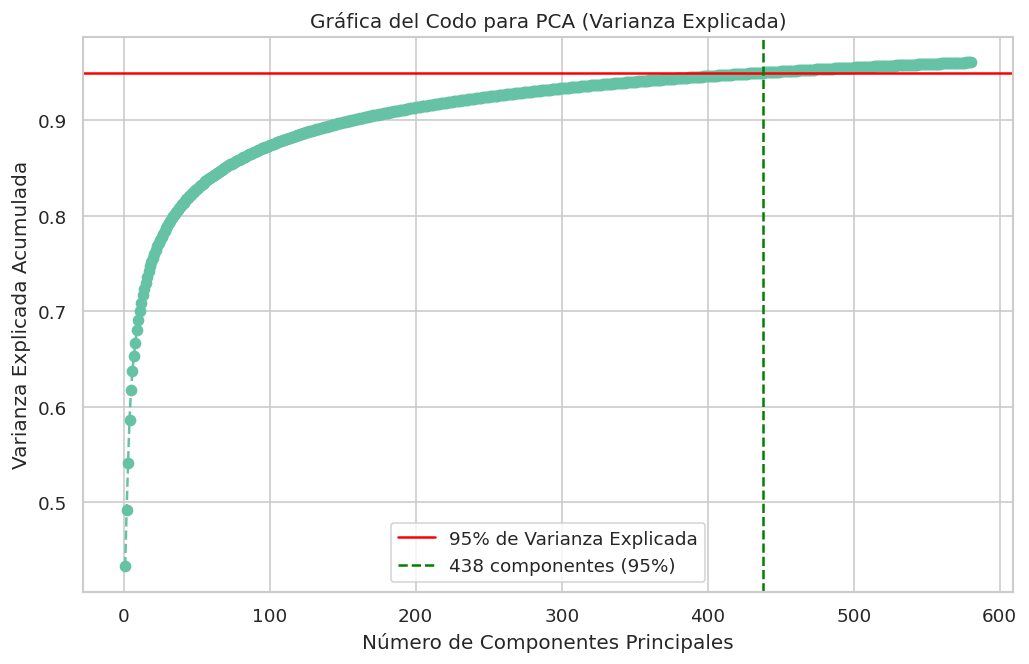

Calculando t-SNE con perplexity=5...
Calculando t-SNE con perplexity=30...
Calculando t-SNE con perplexity=50...
Calculando t-SNE con perplexity=100...


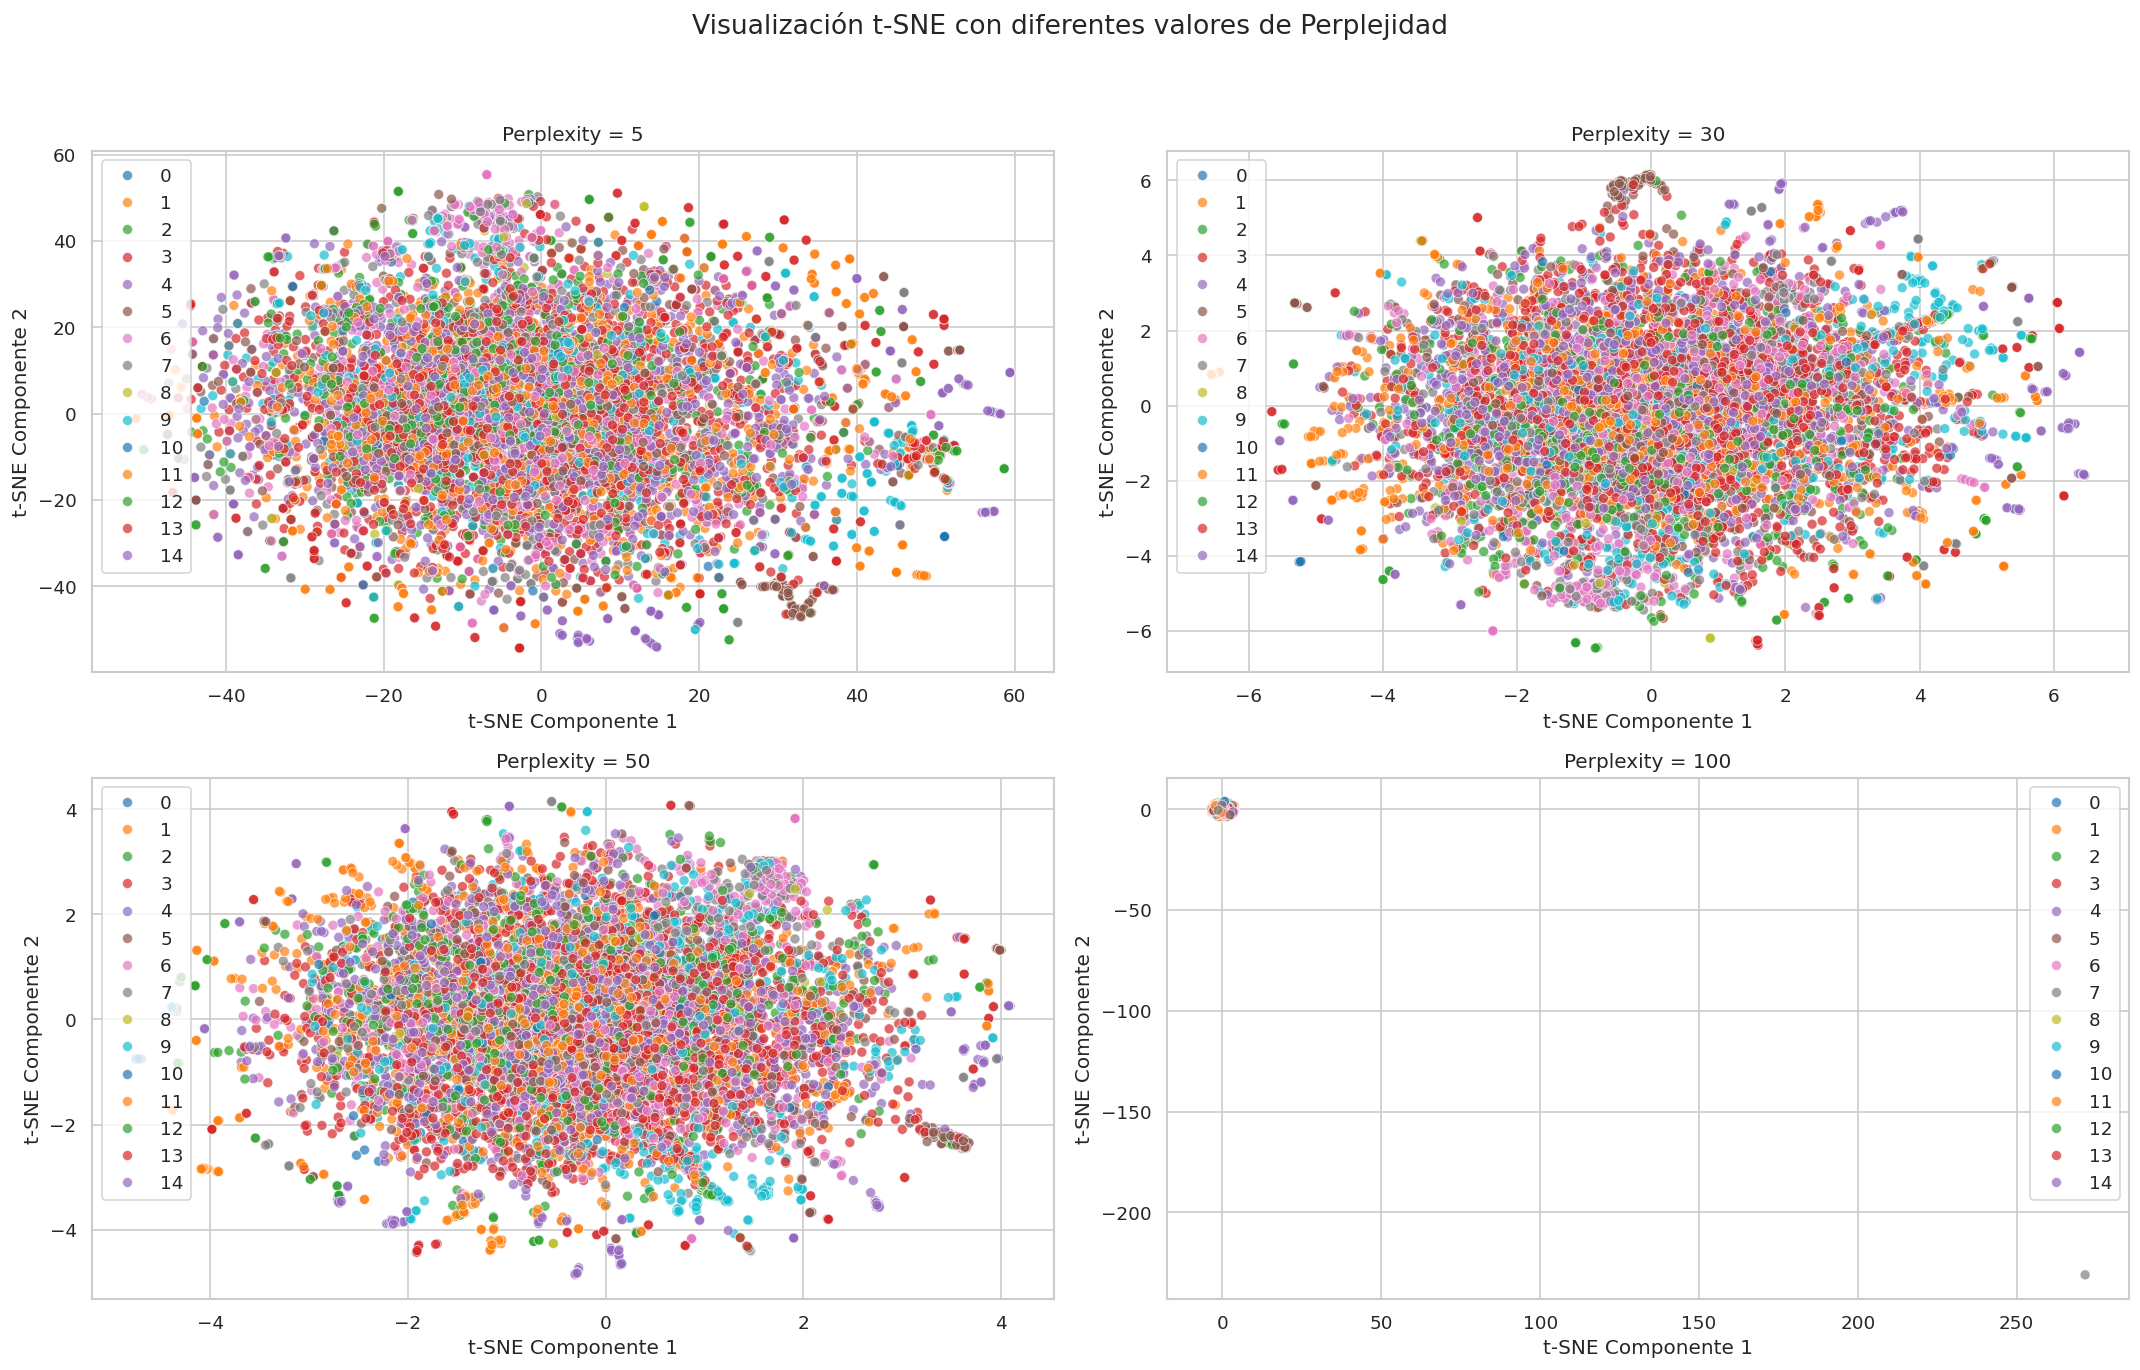

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca_full = PCA(n_components=min(X_train.shape[1], 580), random_state=42)
pca_full.fit(X_train)
explained_variance_ratios = np.cumsum(pca_full.explained_variance_ratio_)
n_components_pca_range = range(1, len(explained_variance_ratios) + 1)

print("Calculando varianza explicada para PCA...")

plt.figure(figsize=(10, 6))
plt.plot(n_components_pca_range, explained_variance_ratios, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Gráfica del Codo para PCA (Varianza Explicada)')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% de Varianza Explicada')

# Encontrar el índice donde la varianza explicada acumulada supera el 95%
idx_95_var = np.argmax(explained_variance_ratios >= 0.95)
# Sumar 1 porque los índices son base 0 y queremos el número de componentes
num_components_at_95 = n_components_pca_range[idx_95_var]

plt.axvline(x=num_components_at_95, color='g', linestyle='--', label=f'{num_components_at_95} componentes (95%)')
plt.legend()
plt.show()


perplexities = [5, 30, 50, 100]

plt.figure(figsize=(18, 12))
plt.suptitle('Visualización t-SNE con diferentes valores de Perplejidad', fontsize=16)

for i, perp in enumerate(perplexities):
    ax = plt.subplot(2, 2, i + 1)
    print(f"Calculando t-SNE con perplexity={perp}...")
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate='auto',
        init='pca',
        random_state=42,
        n_jobs=-1
    )
    X_tsne_current = tsne.fit_transform(X_train_pca)

    sns.scatterplot(
        x=X_tsne_current[:, 0],
        y=X_tsne_current[:, 1],
        hue=y_train,
        palette='tab10',
        legend='full',
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE Componente 1')
    ax.set_ylabel('t-SNE Componente 2')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4.3. Optimización Hiperparamétrica del Número de Clústeres (K)
Somete el espacio dimensional reducido por PCA a un análisis exploratorio de particionamiento iterativo utilizando el algoritmo K-Means con inicialización inteligente (`k-means++`). La rutina calcula y contrasta de manera simultánea dos métricas de validación interna intrínsecas: la Inercia (método del codo), encargada de medir la cohesión interna o dispersión de las muestras respecto a sus centroides, y el Coeficiente de Silueta, encargado de evaluar la calidad de la separación inter-clúster. Ambos resultados se proyectan en una ventana gráfica dual para proveer un diagnóstico robusto que facilite la selección del hiperparámetro óptimo de agrupamiento.

Evaluando métricas para diferentes valores de K...


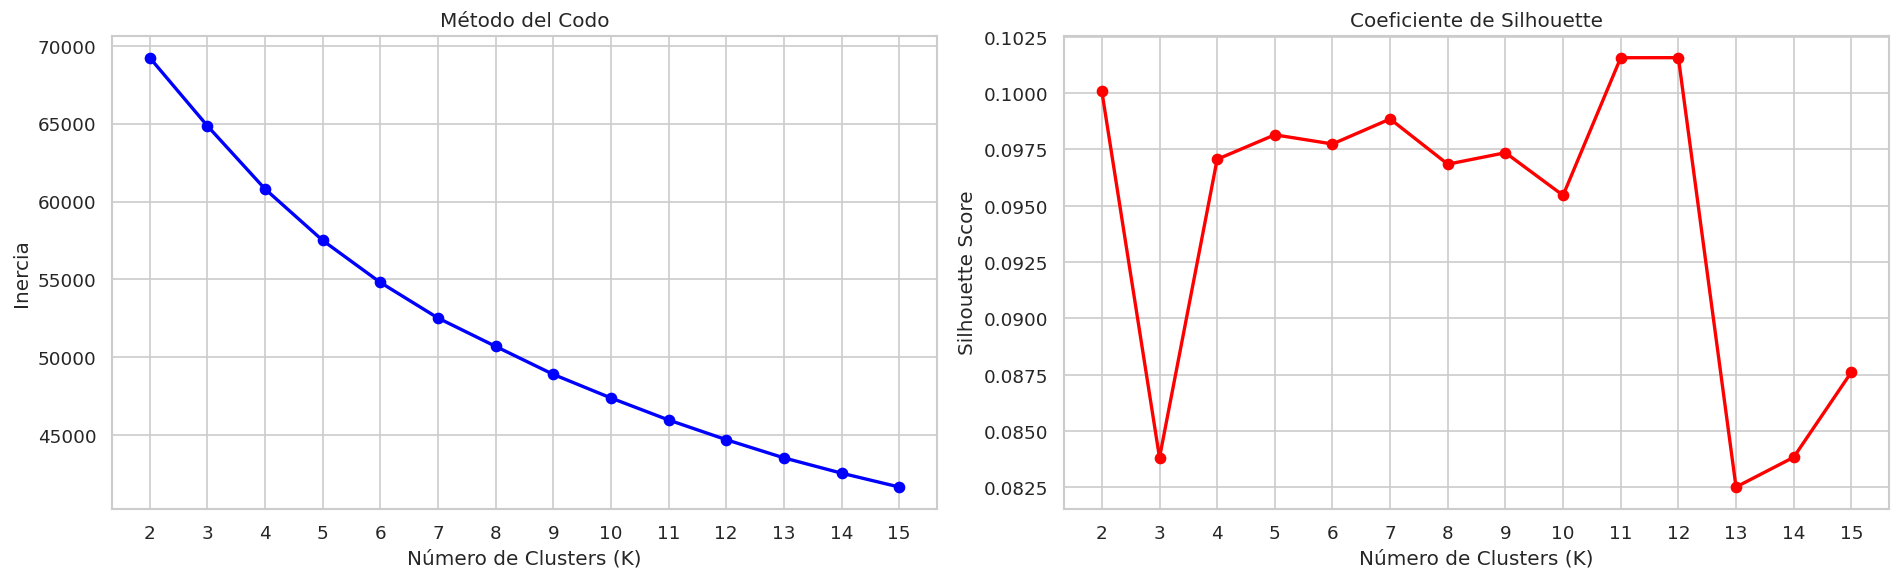

In [ ]:
X_clustering = X_train_pca
k_range = range(2, 16)
inercias = []
silhouette_scores = []

print("Evaluando métricas para diferentes valores de K...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clustering)
    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering, labels))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(k_range, inercias, 'bo-', linewidth=2)
ax[0].set_title('Método del Codo')
ax[0].set_xlabel('Número de Clusters (K)')
ax[0].set_ylabel('Inercia')
ax[0].set_xticks(list(k_range))
ax[0].grid(True)

ax[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2)
ax[1].set_title('Coeficiente de Silhouette')
ax[1].set_xlabel('Número de Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_xticks(list(k_range))
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 4.4. Benchmark Comparativo de Algoritmos de Aprendizaje No Supervisado
Establece un entorno competitivo multimodelo fijando la frontera óptima de clústeres descubierta ($K=6$). La rutina entrena y evalúa de manera simultánea tres paradigmas distintos de aprendizaje no supervisado: un enfoque basado en centroides y particiones (`KMeans`), un enfoque jerárquico aglomerativo con criterio de enlace Ward (`AgglomerativeClustering`) y un enfoque basado en densidad y conectividad espacial (`DBSCAN`). Al finalizar, estructura y ordena los modelos en una matriz analítica en función de su Coeficiente de Silueta, cuantificando adicionalmente la capacidad de cada algoritmo para identificar ruido o puntos atípicos (*outliers*) dentro del espacio geométrico.

In [24]:
best_k = 11

modelos = {
    "KMeans": KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10),
    "Jerarquico": AgglomerativeClustering(n_clusters=best_k, linkage='ward'),
    "DBSCAN": DBSCAN(eps=0.7, min_samples=8)
}
resultados_clustering = {}

for nombre, modelo in modelos.items():
    labels = modelo.fit_predict(X_train_pca)
    n_clusters_labels = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters_labels > 1:
        score_sil = silhouette_score(X_train_pca, labels)
    else:
        score_sil = np.nan

    resultados_clustering[nombre] = {
        "Clusters_Encontrados": n_clusters_labels,
        "Ruido_Outliers": np.sum(labels == -1) if nombre == "DBSCAN" else 0,
        "Silhouette_Score": score_sil
    }

df_comparativa = pd.DataFrame.from_dict(resultados_clustering, orient='index')
print(df_comparativa.sort_values(by="Silhouette_Score", ascending=False))

            Clusters_Encontrados  Ruido_Outliers  Silhouette_Score
Jerarquico                    11               0          0.020203
KMeans                        11               0         -0.016131
DBSCAN                         0            9460               NaN


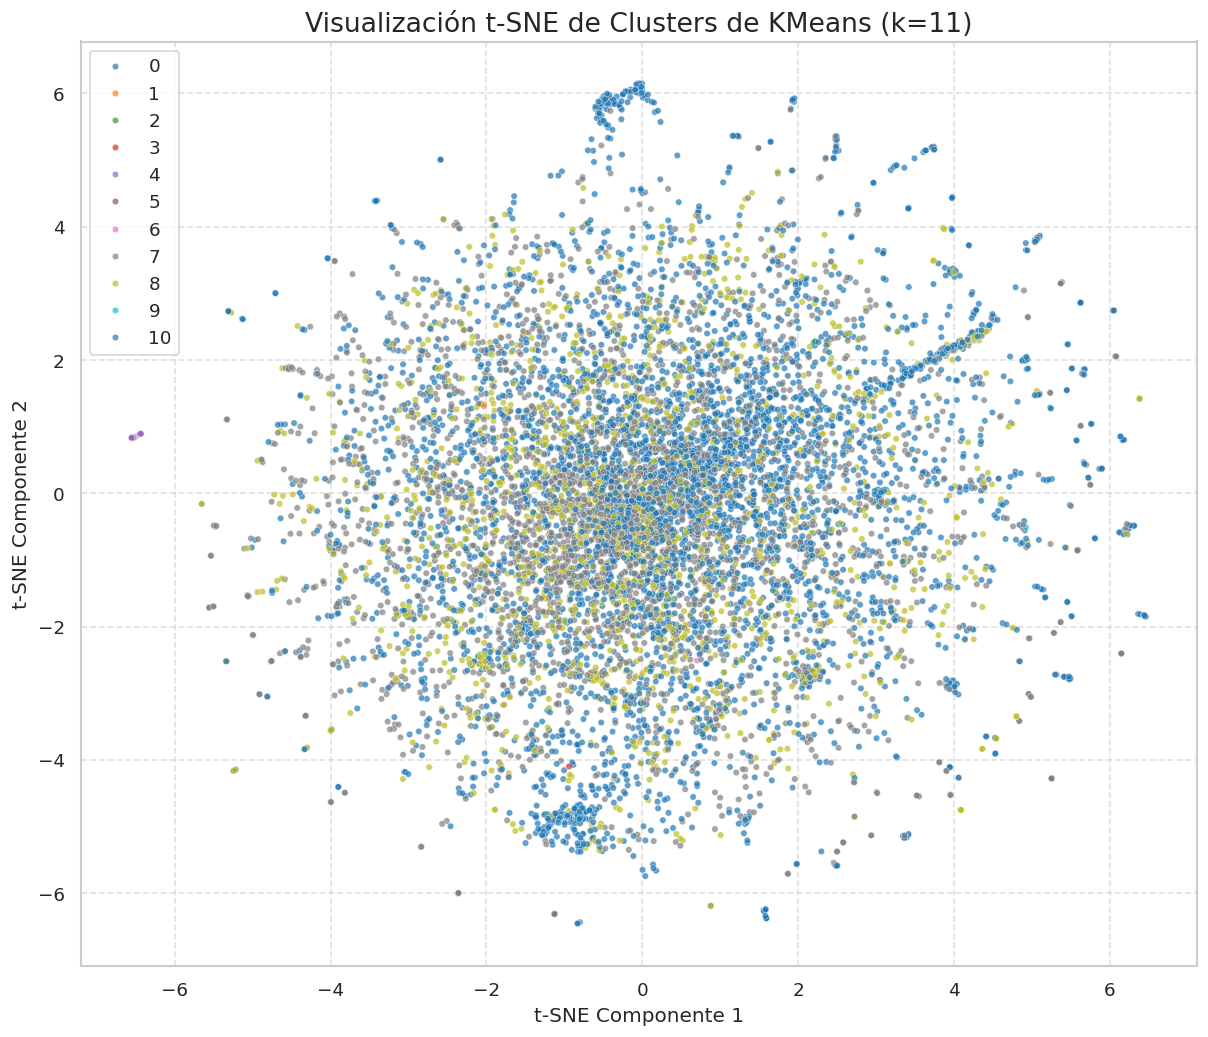

In [25]:
kmeans_model = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_train_pca)
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42, n_jobs=-1)
X_tsne_clusters = tsne.fit_transform(X_train_pca)

plt.figure(figsize=(12, 10))
sns.scatterplot(x=X_tsne_clusters[:, 0], y=X_tsne_clusters[:, 1], hue=kmeans_labels, palette='tab10', legend='full', alpha=0.7, s=15)
plt.title(f'Visualización t-SNE de Clusters de KMeans (k={best_k})', fontsize=16)
plt.xlabel('t-SNE Componente 1', fontsize=12); plt.ylabel('t-SNE Componente 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6); plt.show()

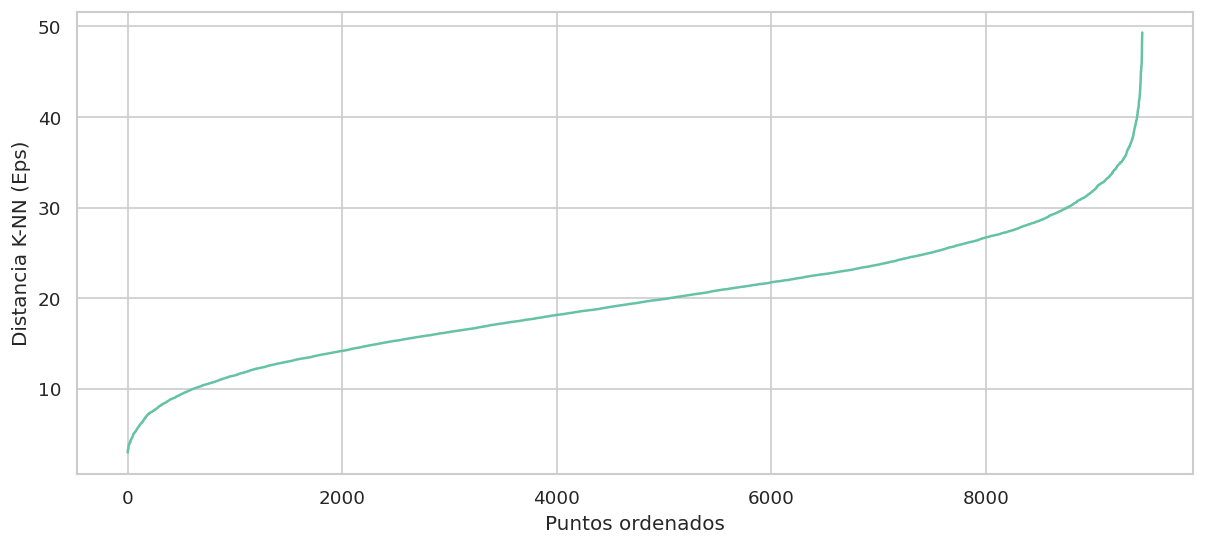

In [21]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 'min_samples' deseado (por ejemplo, 5)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_train_pca)
distances, indices = neighbors_fit.kneighbors(X_train_pca)

# Ordenar las distancias de menor a mayor y graficar
distances = np.sort(distances[:, 4], axis=0)
plt.plot(distances)
plt.ylabel("Distancia K-NN (Eps)")
plt.xlabel("Puntos ordenados")
plt.grid(True)
plt.show()

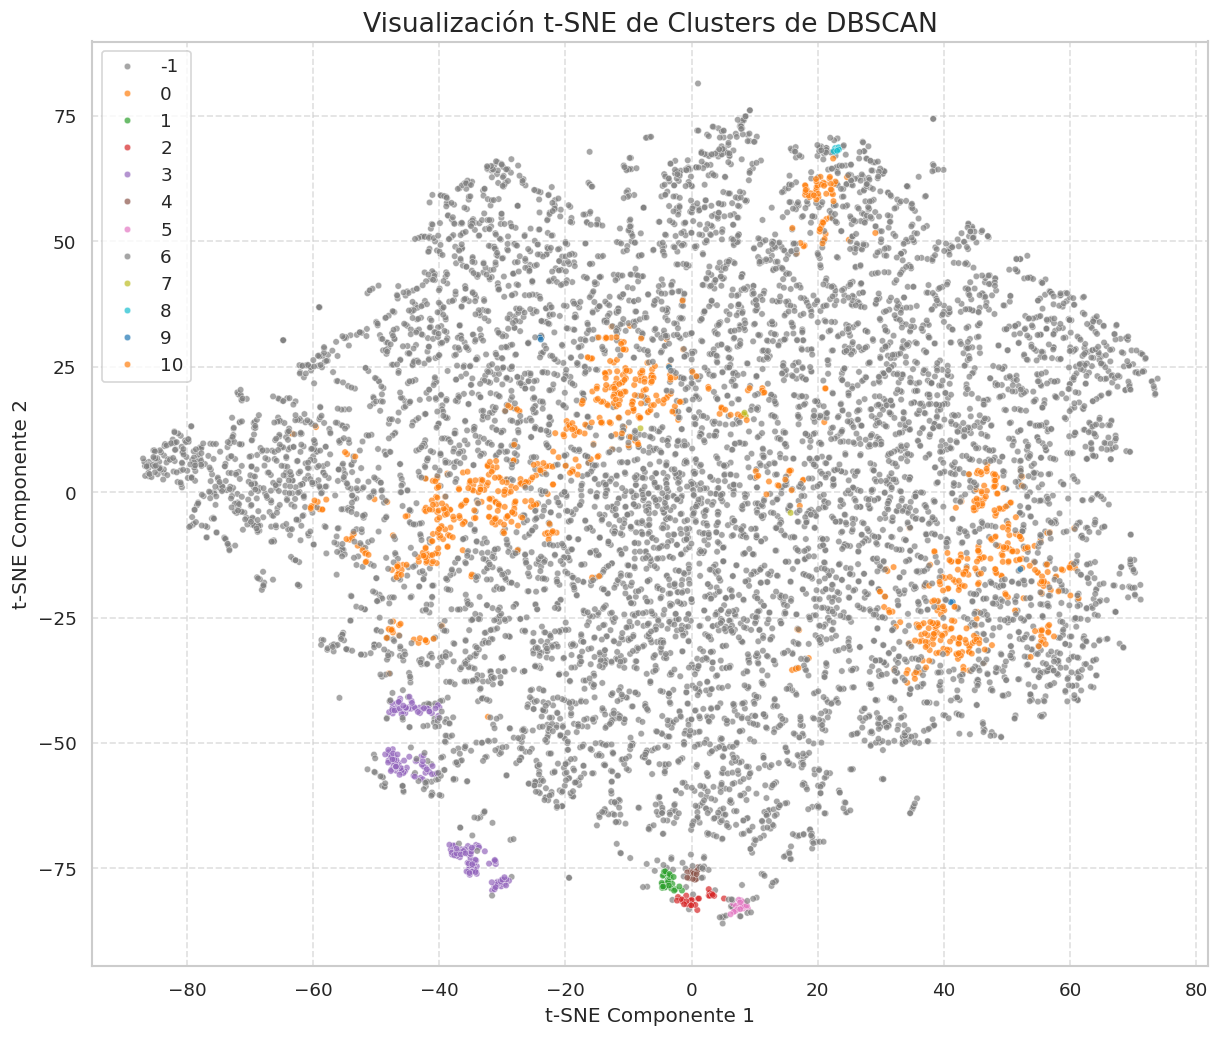

DBSCAN encontró 11 clusters y 8195 puntos de ruido.


In [ ]:
dbscan_model = DBSCAN(eps=0.7, min_samples=8); dbscan_labels = dbscan_model.fit_predict(X_train_pca)
unique_dbscan_labels = np.unique(dbscan_labels); num_clusters = len(unique_dbscan_labels)
palette_dbscan = sns.color_palette('tab10', n_colors=num_clusters)
if -1 in unique_dbscan_labels: palette_dbscan[np.where(unique_dbscan_labels == -1)[0][0]] = (0.5, 0.5, 0.5)

plt.figure(figsize=(12, 10))
sns.scatterplot(x=X_tsne_clusters[:, 0], y=X_tsne_clusters[:, 1], hue=dbscan_labels, palette=palette_dbscan, legend='full', alpha=0.7, s=15)
plt.title('Visualización t-SNE de Clusters de DBSCAN', fontsize=16)
plt.xlabel('t-SNE Componente 1', fontsize=12); plt.ylabel('t-SNE Componente 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6); plt.show()
print(f"DBSCAN encontró {len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)} clusters y {np.sum(dbscan_labels == -1)} puntos de ruido.")

### Visualización t-SNE de Clusters Jerárquicos

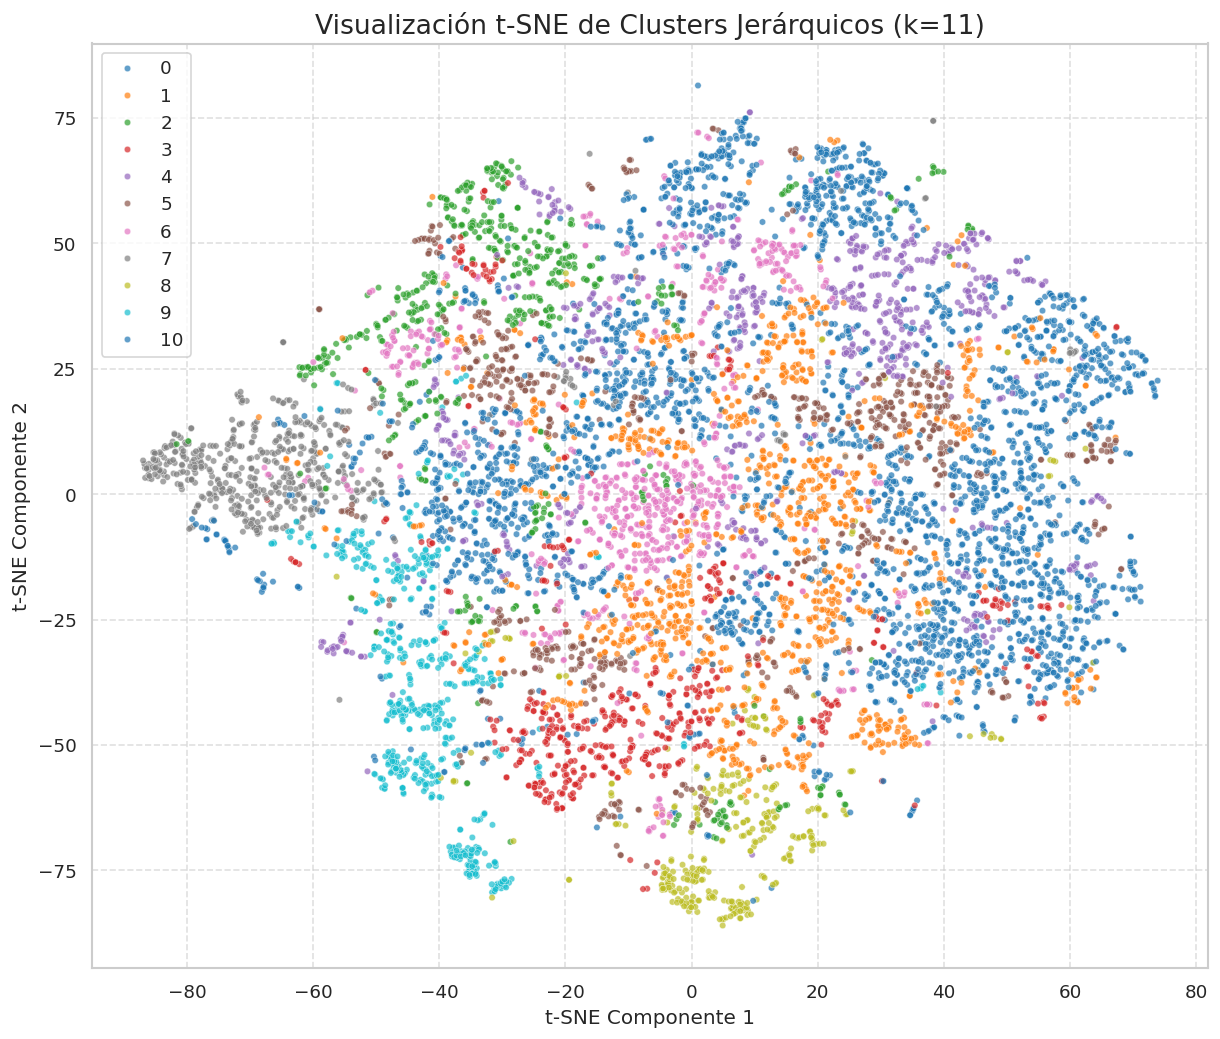

Agglomerative Clustering encontró 11 clusters.


In [ ]:
jerarquico_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward'); jerarquico_labels = jerarquico_model.fit_predict(X_train_pca)

plt.figure(figsize=(12, 10))
sns.scatterplot(x=X_tsne_clusters[:, 0], y=X_tsne_clusters[:, 1], hue=jerarquico_labels, palette='tab10', legend='full', alpha=0.7, s=15)
plt.title(f'Visualización t-SNE de Clusters Jerárquicos (k={best_k})', fontsize=16)
plt.xlabel('t-SNE Componente 1', fontsize=12); plt.ylabel('t-SNE Componente 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6); plt.show()
print(f"Agglomerative Clustering encontró {len(np.unique(jerarquico_labels))} clusters.")